<a href="https://colab.research.google.com/github/ChiaraTagiullo/Machine_Learning_for_NLP/blob/main/03_topic_modeling_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Topic Modeling with LDA

In this notebook, we apply topic modeling to the Archelec corpus in order to uncover latent thematic structures.

The objectives are:

1. Build a document-term matrix suitable for topic modeling.
2. Train Latent Dirichlet Allocation (LDA) models.
3. Select the optimal number of topics using coherence scores.
4. Interpret the discovered topics.
5. Analyse topic distribution across documents.
6. Explore the relationship between topics and metadata (time, political support, etc.).

Topic modeling allows us to move beyond surface-level frequency analysis and identify hidden patterns in the corpus.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archelec_vectorized_with_clusters.xlsx to archelec_vectorized_with_clusters.xlsx


In [2]:
import pandas as pd
import numpy as np

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Shape:", df.shape)
df.head()

Shape: (33029, 37)


,id,date,year,month,contexte-election,contexte-tour,departement,departement-nom,departement-insee,identifiant de circonscription,...,suppleant-soutien,suppleant-liste,text_raw,text_clean,tokens,n_chars,n_words_raw,n_words_clean,support_grouped,cluster
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,1958,11,législatives,1,100.0,Ain,01 - Ain,100.0,...,Parti radical,non mentionné,France;Élections législatives;Assemblée Nation...,ain profession foi emile bouvard industriel bi...,"['ain', 'profession', 'foi', 'emile', 'bouvard...",299,41,18,Other,1
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,1958,11,législatives,1,100.0,Ain,01 - Ain,100.0,...,Union pour la nouvelle République,non mentionné,France;Ve République;Élections législatives;As...,ain profession foi albert jouvent exploitant f...,"['ain', 'profession', 'foi', 'albert', 'jouven...",353,52,18,Other,1
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,1958,11,législatives,1,100.0,Ain,01 - Ain,100.0,...,Parti communiste français,non mentionné,Élections législatives;France;Assemblée Nation...,ain profession foi emile machurat ouvrier poli...,"['ain', 'profession', 'foi', 'emile', 'machura...",280,40,15,Parti communiste français,4
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,1958,11,législatives,1,100.0,Ain,01 - Ain,100.0,...,non mentionné,non mentionné,Élections législatives;France;Assemblée Nation...,ain profession foi amedee mercier maire profes...,"['ain', 'profession', 'foi', 'amedee', 'mercie...",274,38,14,non mentionné,1
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,1958,11,législatives,1,100.0,Ain,01 - Ain,100.0,...,Centre national des indépendants et paysans,non mentionné,Ve République;Assemblée Nationale;Élections lé...,ain profession foi hubert pernin docteur veter...,"['ain', 'profession', 'foi', 'hubert', 'pernin...",360,47,22,Other,1


## 1. Preparing the text for topic modeling

We use the tokenized version of the corpus. Topic modeling requires a clean and consistent representation of documents.

In [3]:
df = df[df["tokens"].notna()].copy()
df = df[df["n_words_clean"] > 3].copy()

df = df.reset_index(drop=True)

print("Documents used:", len(df))

Documents used: 33029


In [4]:
import ast

df["tokens"] = df["tokens"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

## 2. Building the corpus

We convert the tokenized documents into a format suitable for LDA.

In [6]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.5 MB/s eta 0:00:00


In [7]:
from gensim import corpora

dictionary = corpora.Dictionary(df["tokens"])

# Filtriamo termini troppo rari o troppo frequenti
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

print("Number of unique tokens:", len(dictionary))
print("Number of documents:", len(corpus))

Number of unique tokens: 3640
Number of documents: 33029


## 3. Baseline LDA model

We start with a baseline model using a fixed number of topics.

In [8]:
from gensim.models import LdaModel

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10,
    alpha="auto"
)

In [9]:
topics = lda_model.print_topics(num_words=10)

for topic_id, topic in topics:
    print(f"Topic {topic_id}:")
    print(topic)
    print()

Topic 0:
0.088*"ecologistes" + 0.084*"ecologie" + 0.049*"verts" + 0.048*"unie" + 0.045*"ouvriere" + 0.045*"generation" + 0.042*"lutte" + 0.024*"travailleurs" + 0.021*"opposition" + 0.019*"mouvement"

Topic 1:
0.068*"majorite" + 0.055*"progres" + 0.041*"union" + 0.037*"alliance" + 0.036*"presidentielle" + 0.035*"rassemblement" + 0.024*"animaux" + 0.022*"nature" + 0.021*"nouvelle" + 0.021*"nouveaux"

Topic 2:
0.086*"union" + 0.079*"conseiller" + 0.063*"rassemblement" + 0.052*"maire" + 0.049*"democratie" + 0.043*"francaise" + 0.036*"national" + 0.036*"general" + 0.029*"centre" + 0.027*"depute"

Topic 3:
0.135*"parti" + 0.124*"socialiste" + 0.061*"gauche" + 0.036*"mouvement" + 0.027*"radicaux" + 0.021*"maire" + 0.020*"politique" + 0.020*"conseiller" + 0.016*"unifie" + 0.015*"democrate"

Topic 4:
0.141*"francais" + 0.120*"parti" + 0.113*"communiste" + 0.050*"gauche" + 0.041*"forces" + 0.034*"conseiller" + 0.032*"maire" + 0.027*"union" + 0.020*"municipal" + 0.016*"ouvrier"



### Interpretation — Baseline LDA topics

The initial LDA model already reveals meaningful political structures.

Some topics correspond clearly to identifiable political families. One topic captures ecological and alternative political vocabulary, with terms such as "écologistes", "écologie", "verts", and "génération". Another topic is associated with socialist and left-wing vocabulary, including "parti", "socialiste", "gauche", and "radicaux". A further topic is strongly linked to the Communist Party, with terms such as "français", "parti", "communiste", and "ouvrier".

Other topics capture more institutional or center-right vocabulary, with terms such as "union", "rassemblement", "démocratie", "maire", "conseiller", and "député".

These results confirm that topic modeling identifies political identity profiles rather than broad argumentative themes. This is coherent with the structure of the corpus, which is based on short political and biographical descriptors.

## 4. Choosing the number of topics

We evaluate different numbers of topics using coherence score.

In [14]:
from gensim.models import LdaModel, CoherenceModel

def compute_coherence_values_fast(dictionary, corpus, texts, topic_nums):
    coherence_values = []
    models = []

    for num_topics in topic_nums:
        print(f"Training LDA with {num_topics} topics...")

        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=3,
            iterations=50,
            chunksize=2000,
            alpha="auto",
            per_word_topics=False
        )

        models.append(model)

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )

        coherence = coherence_model.get_coherence()
        coherence_values.append(coherence)

        print(f"Coherence for {num_topics} topics: {coherence:.4f}")

    return models, coherence_values

In [15]:
topic_nums = [3, 4, 5, 6, 7]

models, coherence_values = compute_coherence_values_fast(
    dictionary=dictionary,
    corpus=corpus,
    texts=df["tokens"],
    topic_nums=topic_nums
)

Training LDA with 3 topics...
Coherence for 3 topics: 0.3191
Training LDA with 4 topics...
Coherence for 4 topics: 0.3992
Training LDA with 5 topics...
Coherence for 5 topics: 0.3601
Training LDA with 6 topics...
Coherence for 6 topics: 0.3476
Training LDA with 7 topics...
Coherence for 7 topics: 0.3447


### Interpretation — Coherence score and topic selection

The coherence score was computed for different numbers of topics in order to select a suitable LDA specification.

The best result is obtained with 4 topics, with a coherence score of approximately 0.399. After this point, coherence decreases for 5, 6, and 7 topics. This suggests that increasing the number of topics does not improve semantic interpretability, but instead fragments the corpus into less coherent groups.

For this reason, the final LDA model is trained with 4 topics. This choice balances quantitative performance and qualitative interpretability.

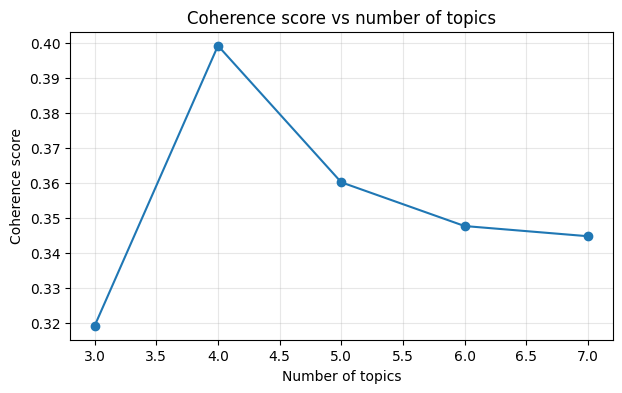

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(topic_nums, coherence_values, marker="o")
plt.xlabel("Number of topics")
plt.ylabel("Coherence score")
plt.title("Coherence score vs number of topics")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Final LDA model

Based on the coherence score, the final LDA model is trained with 4 topics.

The objective is not only to maximize coherence, but also to obtain topics that are interpretable from a political and historical perspective.

In [17]:
optimal_k = 4

final_lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    random_state=42,
    passes=10,
    iterations=100,
    chunksize=2000,
    alpha="auto",
    per_word_topics=False
)

In [18]:
final_topics = final_lda_model.print_topics(num_words=12)

for topic_id, topic in final_topics:
    print(f"Topic {topic_id}:")
    print(topic)
    print()

Topic 0:
0.059*"ecologistes" + 0.056*"ecologie" + 0.033*"verts" + 0.032*"unie" + 0.031*"animaux" + 0.030*"ouvriere" + 0.030*"generation" + 0.028*"lutte" + 0.028*"nature" + 0.026*"nouveaux" + 0.023*"mouvement" + 0.016*"travailleurs"

Topic 1:
0.060*"majorite" + 0.053*"national" + 0.052*"front" + 0.035*"entente" + 0.032*"presidentielle" + 0.027*"politique" + 0.025*"europeennes" + 0.021*"populaire" + 0.020*"conseiller" + 0.018*"nouvelle" + 0.018*"municipal" + 0.016*"union"

Topic 2:
0.104*"union" + 0.086*"rassemblement" + 0.074*"conseiller" + 0.059*"maire" + 0.053*"democratie" + 0.047*"francaise" + 0.037*"general" + 0.032*"depute" + 0.031*"centre" + 0.028*"progres" + 0.024*"sortant" + 0.023*"regional"

Topic 3:
0.154*"parti" + 0.087*"francais" + 0.073*"socialiste" + 0.070*"communiste" + 0.067*"gauche" + 0.034*"conseiller" + 0.032*"maire" + 0.025*"forces" + 0.018*"municipal" + 0.016*"union" + 0.016*"politique" + 0.016*"radicaux"



In [19]:
topic_terms = []

for topic_id in range(optimal_k):
    terms = final_lda_model.show_topic(topic_id, topn=15)
    for term, weight in terms:
        topic_terms.append({
            "topic": topic_id,
            "term": term,
            "weight": weight
        })

topic_terms_df = pd.DataFrame(topic_terms)
topic_terms_df.head(20)

,topic,term,weight
0,0,ecologistes,0.058905
1,0,ecologie,0.055905
2,0,verts,0.032697
3,0,unie,0.031736
4,0,animaux,0.030671
5,0,ouvriere,0.030065
6,0,generation,0.029743
7,0,lutte,0.028038
8,0,nature,0.028016
9,0,nouveaux,0.025949


In [20]:
for topic_id in range(optimal_k):
    print(f"Topic {topic_id}")
    display(
        topic_terms_df[topic_terms_df["topic"] == topic_id]
        .sort_values("weight", ascending=False)
        .head(15)
    )

Topic 0


,topic,term,weight
0,0,ecologistes,0.058905
1,0,ecologie,0.055905
2,0,verts,0.032697
3,0,unie,0.031736
4,0,animaux,0.030671
5,0,ouvriere,0.030065
6,0,generation,0.029743
7,0,lutte,0.028038
8,0,nature,0.028016
9,0,nouveaux,0.025949


Topic 1


,topic,term,weight
15,1,majorite,0.059842
16,1,national,0.053184
17,1,front,0.051992
18,1,entente,0.035441
19,1,presidentielle,0.031880
20,1,politique,0.027313
21,1,europeennes,0.024537
22,1,populaire,0.020992
23,1,conseiller,0.020289
24,1,nouvelle,0.018396


Topic 2


,topic,term,weight
30,2,union,0.104328
31,2,rassemblement,0.086131
32,2,conseiller,0.073566
33,2,maire,0.058633
34,2,democratie,0.053198
35,2,francaise,0.046789
36,2,general,0.037272
37,2,depute,0.032043
38,2,centre,0.031242
39,2,progres,0.027689


Topic 3


,topic,term,weight
45,3,parti,0.154357
46,3,francais,0.087429
47,3,socialiste,0.073489
48,3,communiste,0.069609
49,3,gauche,0.066515
50,3,conseiller,0.033830
51,3,maire,0.031572
52,3,forces,0.025225
53,3,municipal,0.017941
54,3,union,0.016279


In [21]:
doc_topics = []

for doc in corpus:
    topic_probs = final_lda_model.get_document_topics(doc, minimum_probability=0)
    topic_probs = sorted(topic_probs, key=lambda x: x[0])
    doc_topics.append([prob for topic_id, prob in topic_probs])

doc_topics = np.array(doc_topics)

for i in range(optimal_k):
    df[f"topic_{i}"] = doc_topics[:, i]

df["dominant_topic"] = df[[f"topic_{i}" for i in range(optimal_k)]].idxmax(axis=1)
df["dominant_topic_id"] = df["dominant_topic"].str.extract("(\d+)").astype(int)

df[["text_clean", "dominant_topic", "dominant_topic_id"]].head()

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5759/45333892.py:14: SyntaxWarning: invalid escape sequence '\d'
  df["dominant_topic_id"] = df["dominant_topic"].str.extract("(\d+)").astype(int)


,text_clean,dominant_topic,dominant_topic_id
0,ain profession foi emile bouvard industriel bi...,topic_2,2
1,ain profession foi albert jouvent exploitant f...,topic_1,1
2,ain profession foi emile machurat ouvrier poli...,topic_3,3
3,ain profession foi amedee mercier maire profes...,topic_2,2
4,ain profession foi hubert pernin docteur veter...,topic_2,2


In [22]:
topic_distribution = df["dominant_topic_id"].value_counts().sort_index()

topic_distribution

,count
dominant_topic_id,
0,4265
1,6331
2,11299
3,11134


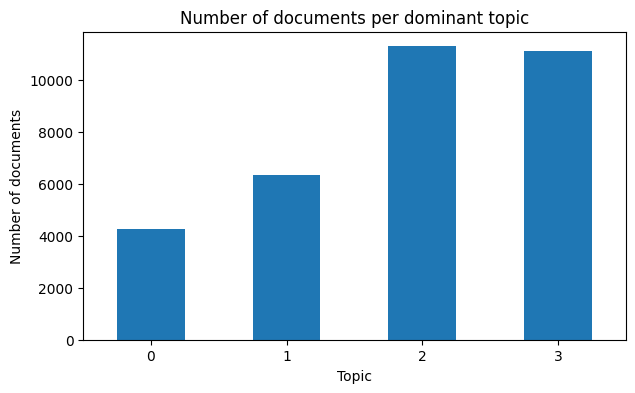

In [23]:
plt.figure(figsize=(7, 4))
topic_distribution.plot(kind="bar")
plt.title("Number of documents per dominant topic")
plt.xlabel("Topic")
plt.ylabel("Number of documents")
plt.xticks(rotation=0)
plt.show()

### Interpretation — Final LDA topics

The final LDA model identifies four distinct and interpretable political profiles.

Topic 0 is characterized by terms such as "écologistes", "écologie", "verts", "animaux", and "nature". This topic clearly corresponds to ecological and environmental political movements, as well as alternative or activist-oriented groups. It represents a more recent and less dominant political vocabulary within the corpus.

Topic 1 includes terms such as "front", "national", "majorité", "entente", and "populaire". This topic appears to capture right-wing and far-right political vocabulary, including references to national identity and political alliances. It also includes electoral and institutional terms such as "présidentielle" and "municipal".

Topic 2 is dominated by terms such as "union", "rassemblement", "démocratie", "centre", "député", and "maire". This topic reflects a mainstream institutional and center-right political profile, structured around governance, parliamentary roles, and political coalitions. It corresponds to a broad and dominant segment of the corpus.

Topic 3 includes terms such as "parti", "socialiste", "communiste", "gauche", and "radicaux". This topic clearly captures left-wing political traditions, including both socialist and communist vocabularies. It represents a major ideological axis in the corpus.

Overall, the topics do not represent abstract themes, but rather structured political identity profiles. This confirms that the corpus is primarily organized around party affiliation, ideological positioning, and institutional roles.

In [24]:
topic_names = {
    0: "Ecological and alternative movements",
    1: "Right-wing and nationalist politics",
    2: "Institutional and center-right governance",
    3: "Left-wing and socialist/communist politics"
}

df["topic_name"] = df["dominant_topic_id"].map(topic_names)

df[["dominant_topic_id", "topic_name"]].head()

,dominant_topic_id,topic_name
0,2,Institutional and center-right governance
1,1,Right-wing and nationalist politics
2,3,Left-wing and socialist/communist politics
3,2,Institutional and center-right governance
4,2,Institutional and center-right governance


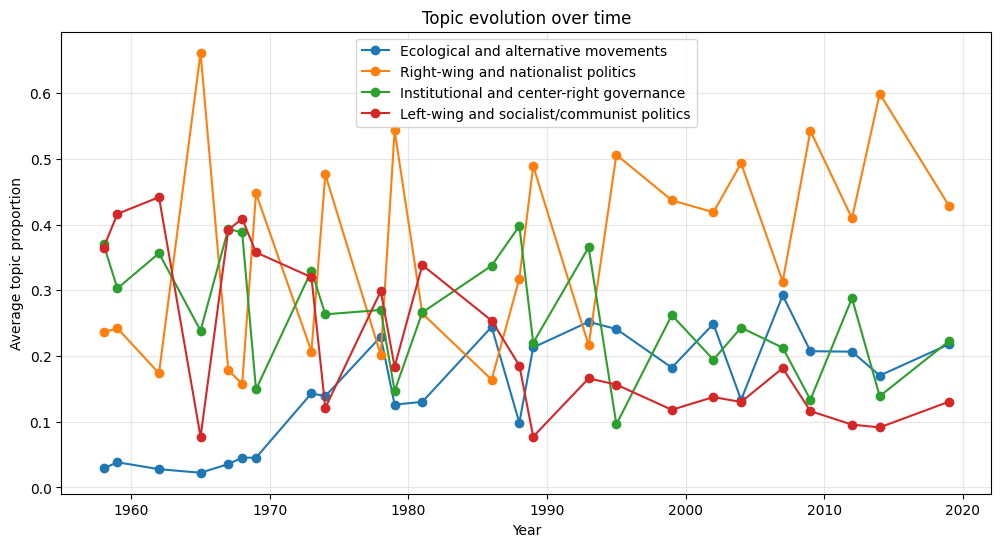

In [25]:
topic_cols = [f"topic_{i}" for i in range(optimal_k)]

topic_time = df.groupby("year")[topic_cols].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i in range(optimal_k):
    plt.plot(topic_time.index, topic_time[f"topic_{i}"], marker="o", label=topic_names[i])

plt.title("Topic evolution over time")
plt.xlabel("Year")
plt.ylabel("Average topic proportion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation — Topic evolution over time

The temporal evolution of topics reveals several important patterns in the political structure of the corpus.

The topic corresponding to right-wing and nationalist politics (Topic 1) appears consistently dominant across many years, often reaching the highest proportions. This suggests that this political profile is strongly represented in the dataset and remains stable over time.

The institutional and center-right governance topic (Topic 2) also shows a persistent presence, although with more moderate fluctuations. This reflects the importance of institutional political actors and governing coalitions in electoral contexts.

The left-wing and socialist/communist topic (Topic 3) is more prominent in earlier decades, particularly in the 1960s and 1970s, where it reaches relatively high proportions. This is consistent with the historical importance of left-wing political alliances in that period. Over time, its relative importance appears to decline.

Finally, the ecological and alternative movements topic (Topic 0) remains marginal in earlier years but becomes more visible in later periods, especially from the 1980s onward. This reflects the historical emergence of environmental and alternative political movements in France.

Overall, the results capture both long-term ideological structures (left vs right) and historical shifts, although they must be interpreted with caution due to the uneven temporal distribution of the corpus.

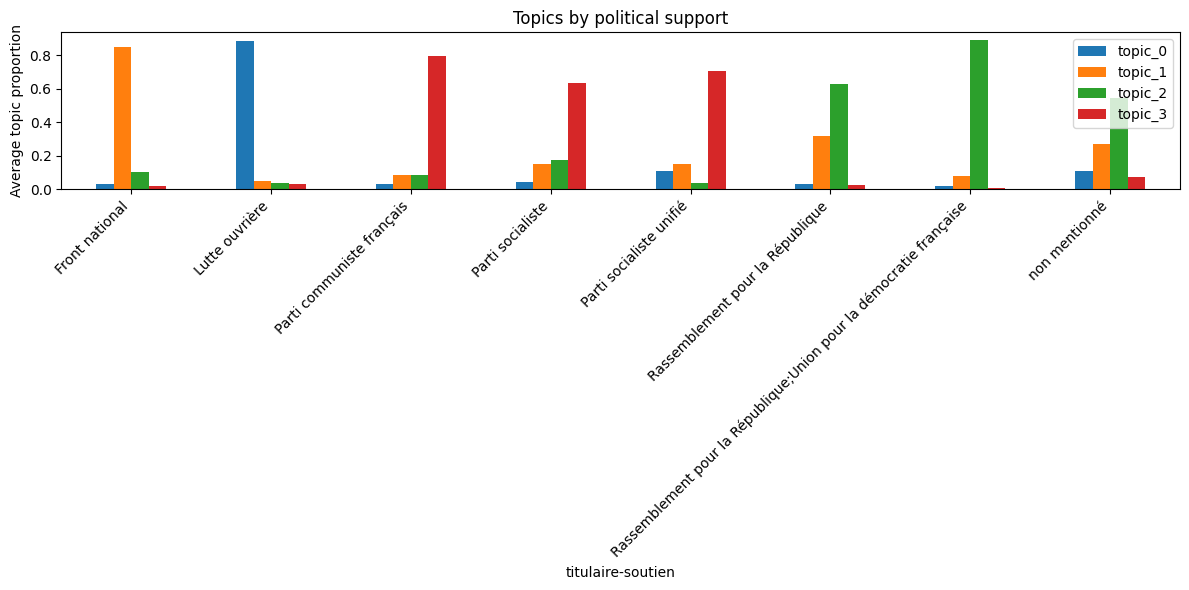

In [26]:
top_supports = df["titulaire-soutien"].value_counts().head(8).index

df_support = df[df["titulaire-soutien"].isin(top_supports)].copy()

topic_by_support = df_support.groupby("titulaire-soutien")[topic_cols].mean()

topic_by_support.plot(kind="bar", figsize=(12, 6))
plt.title("Topics by political support")
plt.ylabel("Average topic proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation — Topics by political support

The distribution of topics across political supports provides strong validation of the LDA model.

Political parties and movements show clear associations with specific topics. For example, "Front national" is strongly associated with Topic 1 (right-wing and nationalist politics), confirming that this topic captures the expected ideological vocabulary.

Left-wing parties such as the Communist Party and Socialist Party are strongly associated with Topic 3, which includes terms related to socialism, communism, and left-wing alliances. This confirms that the model successfully identifies a coherent left-wing political profile.

Center-right coalitions such as "Rassemblement pour la République" and "Union pour la démocratie française" are mainly associated with Topic 2, which captures institutional and governance-related vocabulary.

More specific or niche political movements, such as "Lutte ouvrière", show strong association with Topic 0, reflecting alternative or activist-oriented political language.

Overall, the alignment between topics and political labels demonstrates that the LDA model captures meaningful ideological structures rather than arbitrary word groupings.

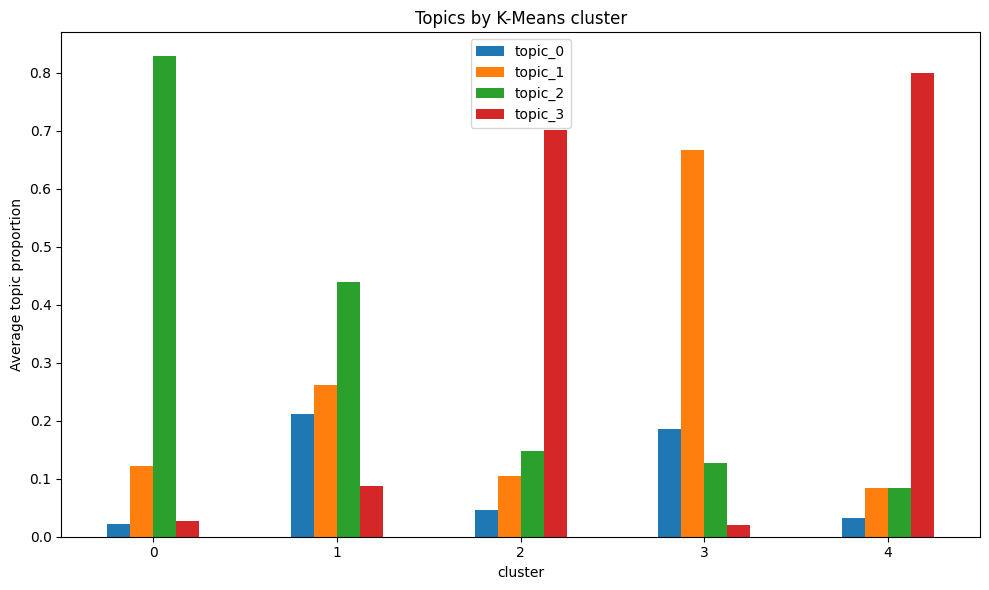

In [27]:
if "cluster" in df.columns:
    topic_by_cluster = df.groupby("cluster")[topic_cols].mean()

    topic_by_cluster.plot(kind="bar", figsize=(10, 6))
    plt.title("Topics by K-Means cluster")
    plt.ylabel("Average topic proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Interpretation — Topics by K-Means cluster

The comparison between LDA topics and K-Means clusters highlights a strong relationship between the two unsupervised approaches.

Each cluster tends to be dominated by a specific topic. For instance, one cluster is strongly associated with Topic 2 (institutional and center-right governance), while another cluster is almost entirely dominated by Topic 3 (left-wing and socialist/communist politics).

This confirms that both methods capture similar underlying structures in the data, despite relying on different modeling assumptions. K-Means groups documents based on geometric proximity in the TF-IDF space, while LDA models documents as mixtures of latent topics.

The partial alignment between clusters and topics strengthens the interpretation that the corpus is organized around distinct political identity profiles.

In [28]:
for topic_id in range(optimal_k):
    print("="*100)
    print(f"Topic {topic_id} — {topic_names[topic_id]}")
    print("="*100)

    examples = df[df["dominant_topic_id"] == topic_id] \
        .sort_values(f"topic_{topic_id}", ascending=False) \
        .head(5)

    for _, row in examples.iterrows():
        print("Year:", row.get("year"))
        print("Support:", row.get("titulaire-soutien"))
        print("Profession:", row.get("titulaire-profession"))
        print("Text:", row["text_clean"][:400])
        print("-"*80)

Topic 0 — Ecological and alternative movements
Year: 1993
Support: Chasse pêche nature traditions;Collectif du monde rural pour le non à Maastricht
Profession: non mentionné
Text: bouches rhone profession foi jean louis savoret chasse peche nature traditions collectif monde rural maastricht enjeu chasse peche nature traditions collectif monde rural maastricht enjeu
--------------------------------------------------------------------------------
Year: 1978
Support: Comités communistes autogestionnaires
Profession: enseignant
Text: rhone profession foi dominique ghisoni enseignant politique comites communistes autogestionnaires socialisme pouvoir travailleurs employee librairie environnement politique comites communistes autogestionnaires socialisme pouvoir travailleurs
--------------------------------------------------------------------------------
Year: 1981
Support: Nord-Ecologie;Vallée de la Lys-Nature;Nord-Nature
Profession: non mentionné
Text: nord profession foi caron nord ecologi

### Interpretation — Representative documents

The inspection of representative documents provides strong qualitative validation of the topic model.

For Topic 0 (ecological and alternative movements), the documents include references to environmental organizations, ecological movements, and activist groups. Terms such as "écologie", "nature", and references to local environmental groups confirm the interpretation of this topic.

For Topic 1 (right-wing and nationalist politics), documents include references to the "Front national", conservative movements, and national identity. The presence of terms related to defense, family, and national values supports this interpretation.

For Topic 2 (institutional and center-right governance), the documents are strongly characterized by references to mainstream political coalitions such as RPR and UDF, as well as institutional roles such as "maire", "conseiller", and "député". This confirms that the topic captures a governing and institutional political profile.

For Topic 3 (left-wing and socialist/communist politics), the documents include extensive references to the Communist Party, Socialist Party, and left-wing alliances. The repeated co-occurrence of these organizations in the same documents clearly validates the topic interpretation.

Overall, the qualitative analysis confirms that the LDA topics correspond to coherent and interpretable political profiles, rather than random statistical groupings.

In [29]:
df.to_excel("archelec_LDA_final.xlsx", index=False)
df.to_csv("archelec_LDA_final.csv", index=False)

from google.colab import files
files.download("archelec_LDA_final.xlsx")
files.download("archelec_LDA_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusions

The topic modeling analysis reveals a clear and interpretable structure in the Archelec corpus.

Using coherence score, the optimal number of topics was identified as four. This relatively small number of topics provides a balance between statistical coherence and interpretability.

The resulting topics correspond to major political identity profiles:

- ecological and alternative movements;
- right-wing and nationalist politics;
- institutional and center-right governance;
- left-wing and socialist/communist politics.

These profiles are not abstract themes but reflect concrete political organizations, alliances, and ideological traditions. This confirms that the corpus is structured primarily around political identity rather than narrative discourse.

The analysis of topic distribution shows that institutional and major political groups dominate the dataset, while alternative or niche movements are less represented.

The temporal analysis highlights both stability and change in the political landscape. Traditional left-right divisions are clearly visible, while newer political movements such as ecological groups emerge later in the timeline.

The comparison with political support metadata provides strong validation of the model, as topics align closely with known political affiliations. Similarly, the comparison with clustering results shows that different unsupervised methods capture consistent structures.

Finally, the qualitative analysis of representative documents confirms that each topic corresponds to a coherent and meaningful political profile.

Despite limitations such as short document length, metadata-driven text, and uneven temporal coverage, topic modeling proves to be a powerful tool for uncovering latent political structures in the corpus.

Overall, the results demonstrate that the Archelec corpus contains rich and interpretable patterns that can be effectively analyzed using NLP methods.